In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv(
    r"C:\Users\Nithin\OneDrive\Desktop\Projects\Spatial–Temporal Uber Fare Prediction Engine\Data\Cleaned data\cleaned_uber_data.csv"
)

df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,Month,Day,Hour,Minute,Weekday,Peak_Hour,Distance_km,Distance_Category,Fare_Category
0,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,52,Thursday,Peak,1.683323,Very Short,Low
1,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4,Friday,Peak,2.457590,Short,Low
2,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,45,Monday,Non Peak,5.036377,Medium,Medium
3,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,22,Friday,Peak,1.661683,Very Short,Low
4,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,47,Thursday,Peak,4.475450,Short,Medium


In [5]:
print(df.shape)

df.info()

df.describe()

(178585, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178585 entries, 0 to 178584
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                178585 non-null  object 
 1   fare_amount        178585 non-null  float64
 2   pickup_datetime    178585 non-null  object 
 3   pickup_longitude   178585 non-null  float64
 4   pickup_latitude    178585 non-null  float64
 5   dropoff_longitude  178585 non-null  float64
 6   dropoff_latitude   178585 non-null  float64
 7   passenger_count    178585 non-null  int64  
 8   Year               178585 non-null  int64  
 9   Month              178585 non-null  int64  
 10  Day                178585 non-null  int64  
 11  Hour               178585 non-null  int64  
 12  Minute             178585 non-null  int64  
 13  Weekday            178585 non-null  object 
 14  Peak_Hour          178585 non-null  object 
 15  Distance_km        178585 non-null  fl

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,Month,Day,Hour,Minute,Distance_km
count,178585.000000,178585.000000,178585.000000,178585.000000,178585.000000,178585.000000,178585.000000,178585.000000,178585.000000,178585.000000,178585.000000,178585.000000
mean,8.943532,-73.939638,40.714353,-73.928073,40.695828,1.688232,2011.701582,6.264893,15.708945,13.533555,29.559403,4.021510
std,4.138356,5.357861,5.566389,8.845131,4.020066,1.392806,1.857747,3.443151,8.685293,6.511012,17.335904,96.390816
min,0.010000,-1340.648410,-74.009697,-3356.666300,-881.985513,1.000000,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,5.700000,-73.992591,40.737095,-73.991853,40.736840,1.000000,2010.000000,3.000000,8.000000,9.000000,14.000000,1.199045
50%,8.000000,-73.982499,40.753186,-73.981223,40.753832,1.000000,2012.000000,6.000000,16.000000,14.000000,30.000000,1.990088
75%,11.000000,-73.970239,40.766870,-73.967936,40.767796,2.000000,2013.000000,9.000000,23.000000,19.000000,45.000000,3.308196
max,22.200000,57.418457,1644.421482,1153.572603,872.697628,208.000000,2015.000000,12.000000,31.000000,23.000000,59.000000,16409.239135


In [7]:
df.isnull().sum()

key                     0
fare_amount             0
pickup_datetime         0
pickup_longitude        0
pickup_latitude         0
dropoff_longitude       0
dropoff_latitude        0
passenger_count         0
Year                    0
Month                   0
Day                     0
Hour                    0
Minute                  0
Weekday                 0
Peak_Hour               0
Distance_km             0
Distance_Category    1932
Fare_Category           0
dtype: int64

In [9]:
import numpy as np

df["Distance_Category"] = pd.cut(
    df["Distance_km"],
    bins=[0, 2, 5, 10, 20, np.inf],
    labels=[
        "Very Short",
        "Short",
        "Medium",
        "Long",
        "Very Long"
    ],
    include_lowest=True
)

In [11]:
df["Distance_Category"].isnull().sum()

0

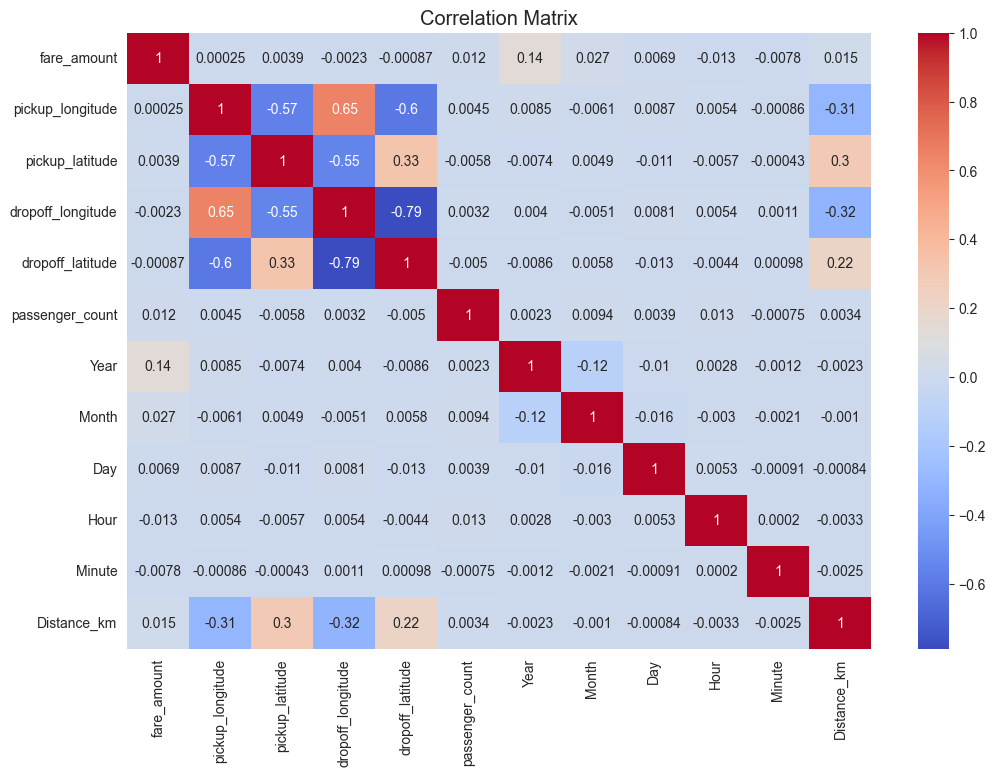

In [13]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

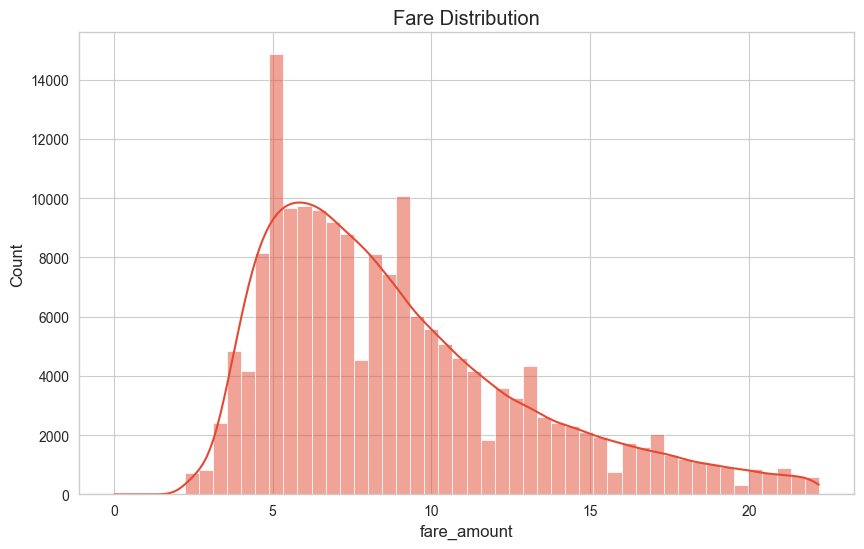

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["fare_amount"],
    bins=50,
    kde=True
)

plt.title("Fare Distribution")

plt.show()

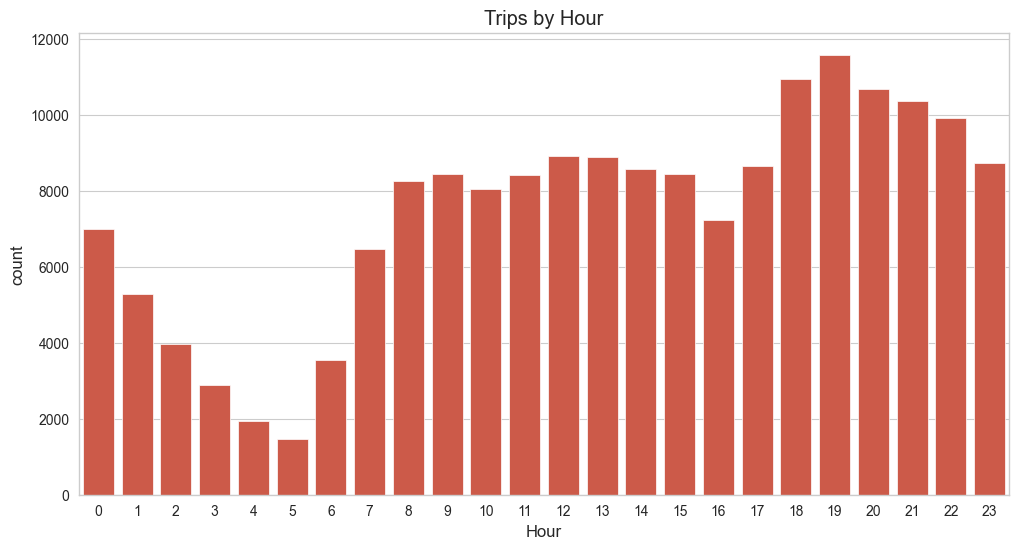

In [17]:
plt.figure(figsize=(12,6))

sns.countplot(
    x=df["Hour"]
)

plt.title("Trips by Hour")

plt.show()

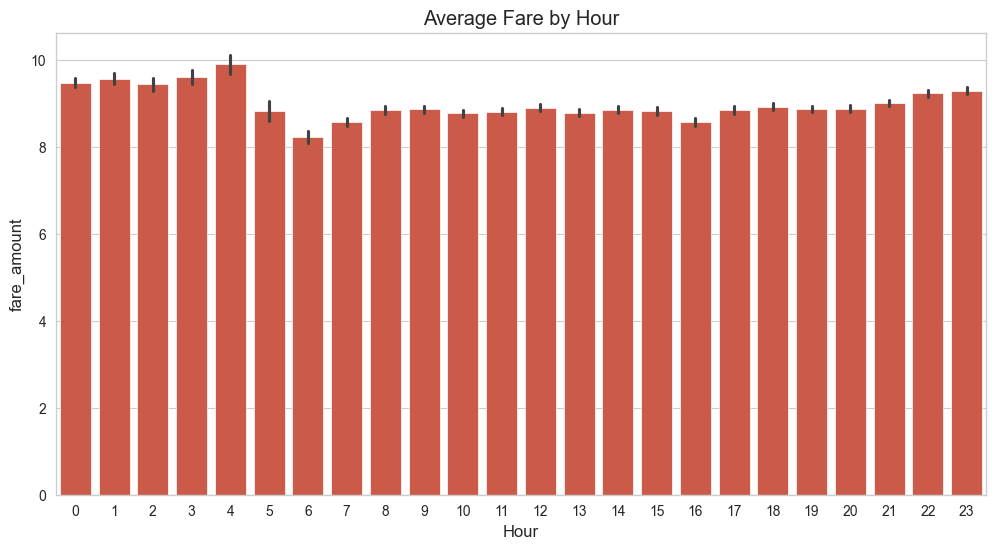

In [19]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x="Hour",
    y="fare_amount"
)

plt.title("Average Fare by Hour")

plt.show()

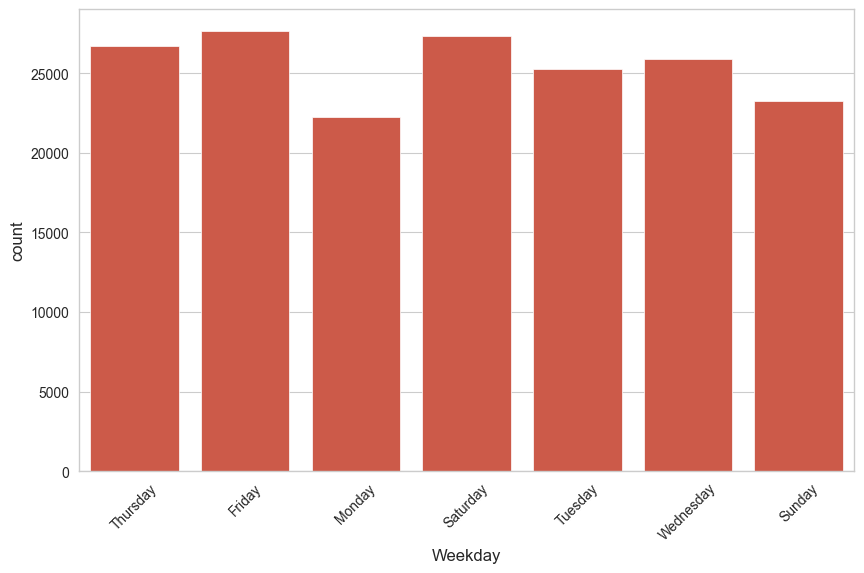

In [21]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Weekday"
)

plt.xticks(rotation=45)

plt.show()

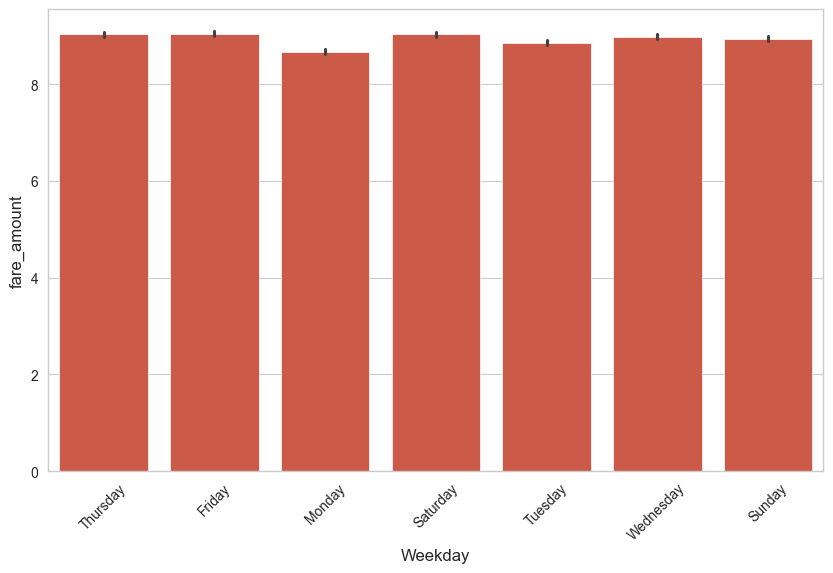

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="Weekday",
    y="fare_amount"
)

plt.xticks(rotation=45)

plt.show()

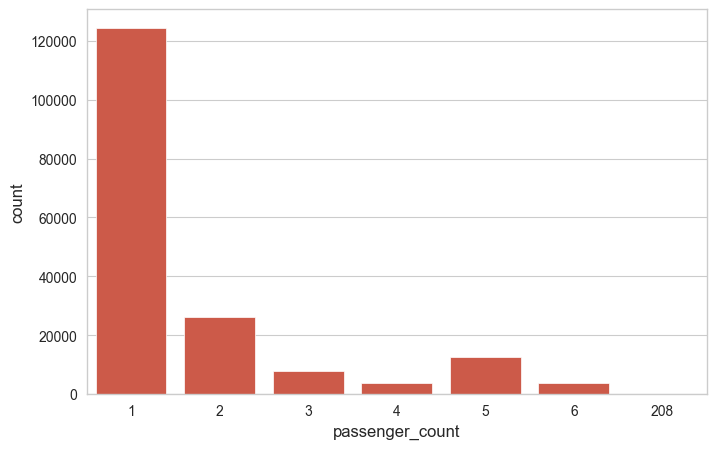

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=df["passenger_count"]
)

plt.show()

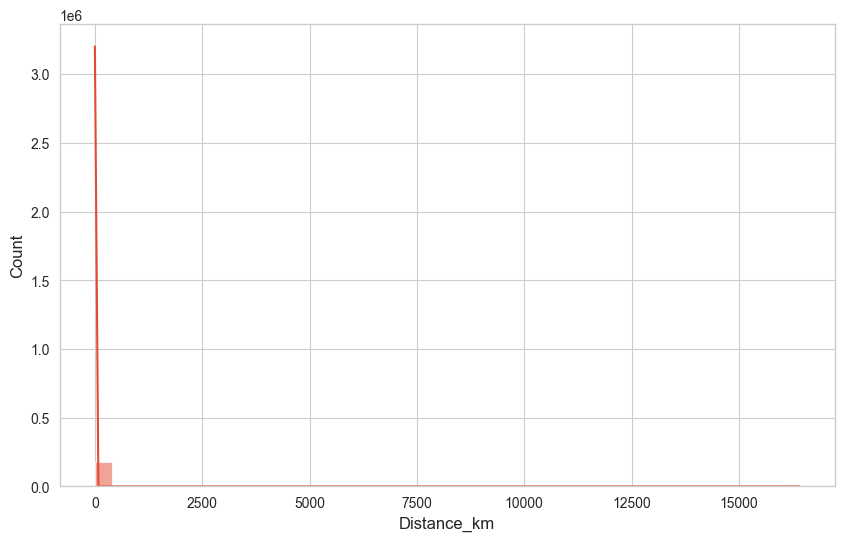

In [27]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Distance_km"],
    bins=40,
    kde=True
)

plt.show()

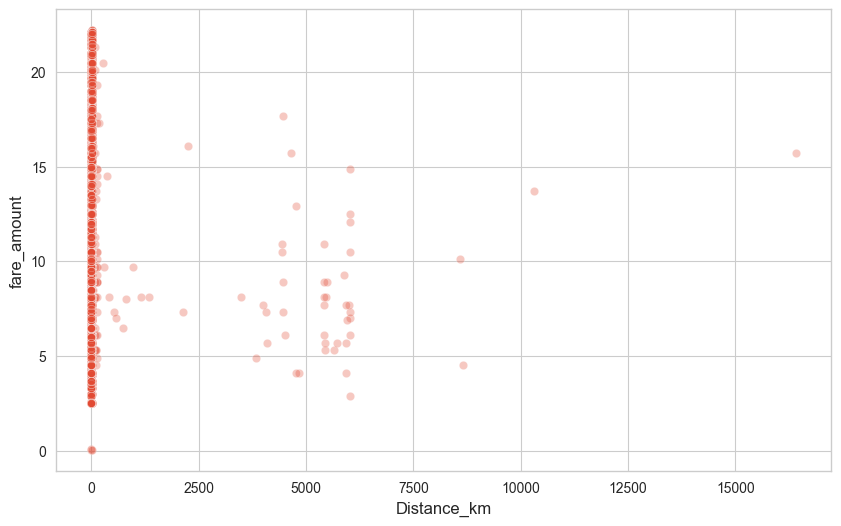

In [29]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Distance_km",
    y="fare_amount",
    alpha=0.3
)

plt.show()

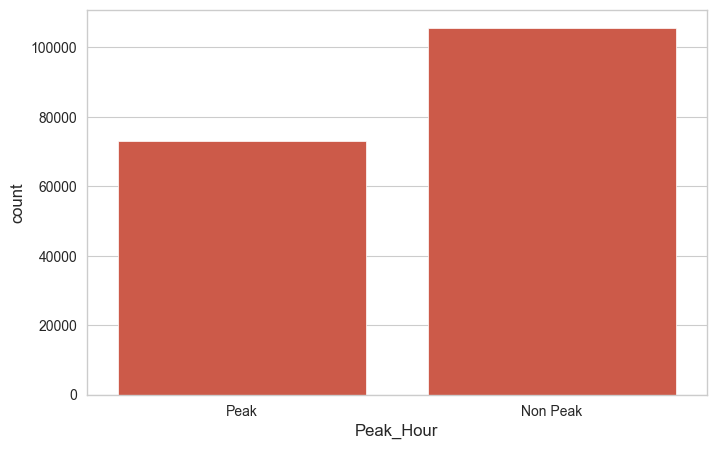

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=df["Peak_Hour"]
)

plt.show()

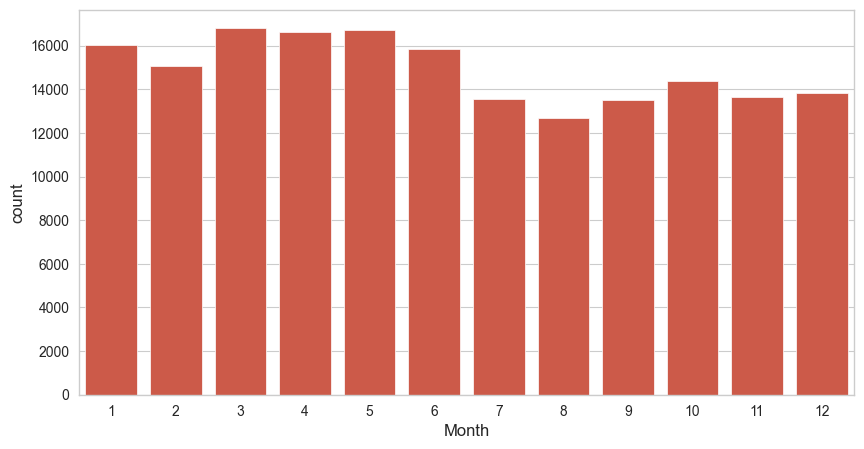

In [33]:
plt.figure(figsize=(10,5))

sns.countplot(
    x=df["Month"]
)

plt.show()

In [35]:
plt.savefig(
    r"C:\Users\Nithin\OneDrive\Desktop\Projects\Spatial–Temporal Uber Fare Prediction Engine\Images\fare_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

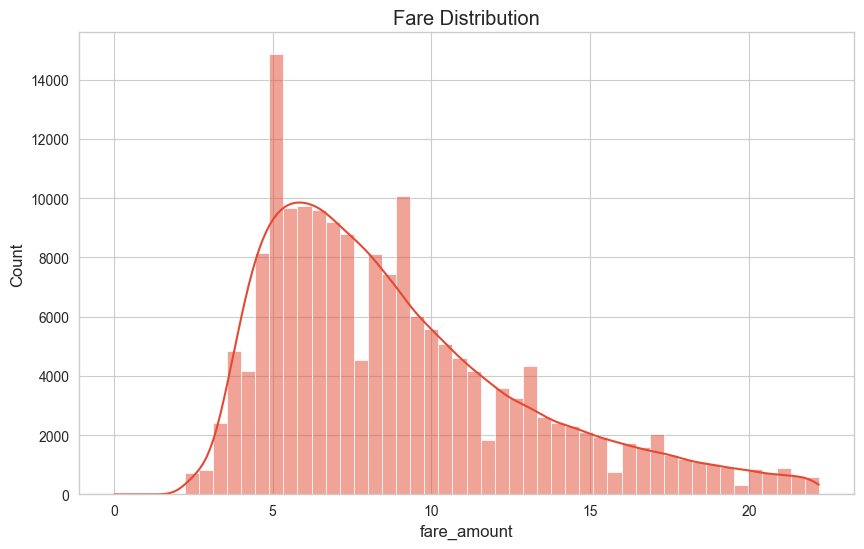

In [37]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["fare_amount"],
    bins=50,
    kde=True
)

plt.title("Fare Distribution")

plt.savefig(
    r"C:\Users\Nithin\OneDrive\Desktop\Projects\Spatial–Temporal Uber Fare Prediction Engine\Images\fare_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

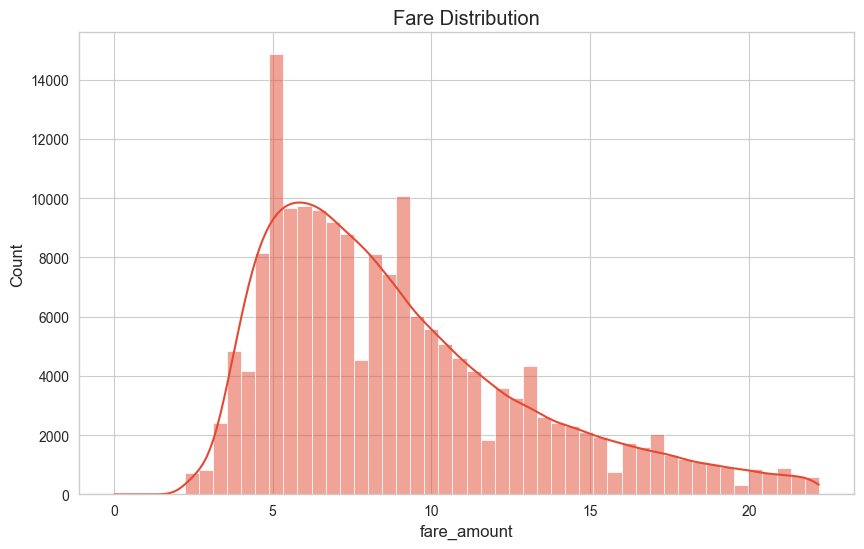

In [39]:
fig, ax = plt.subplots(figsize=(10,6))

sns.histplot(
    df["fare_amount"],
    bins=50,
    kde=True,
    ax=ax
)

ax.set_title("Fare Distribution")

fig.savefig(
    r"C:\Users\Nithin\OneDrive\Desktop\Projects\Spatial–Temporal Uber Fare Prediction Engine\Images\fare_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
import os

os.makedirs(
    r"C:\Users\Nithin\OneDrive\Desktop\Projects\Spatial–Temporal Uber Fare Prediction Engine\Images",
    exist_ok=True
)

In [43]:
def save_plot(name):
    plt.savefig(
        rf"C:\Users\Nithin\OneDrive\Desktop\Projects\Spatial–Temporal Uber Fare Prediction Engine\Images\{name}.png",
        dpi=300,
        bbox_inches="tight"
    )

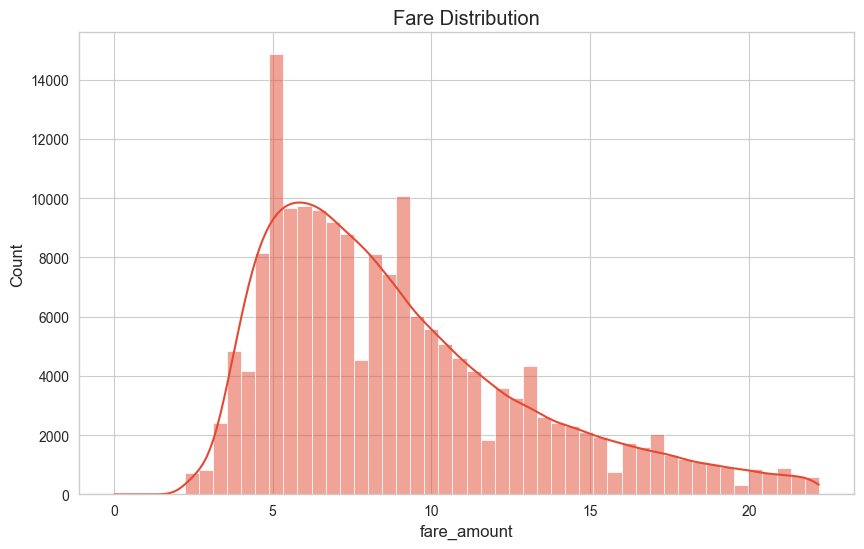

In [45]:
plt.figure(figsize=(10,6))

sns.histplot(df["fare_amount"], bins=50, kde=True)

plt.title("Fare Distribution")

save_plot("fare_distribution")

plt.show()

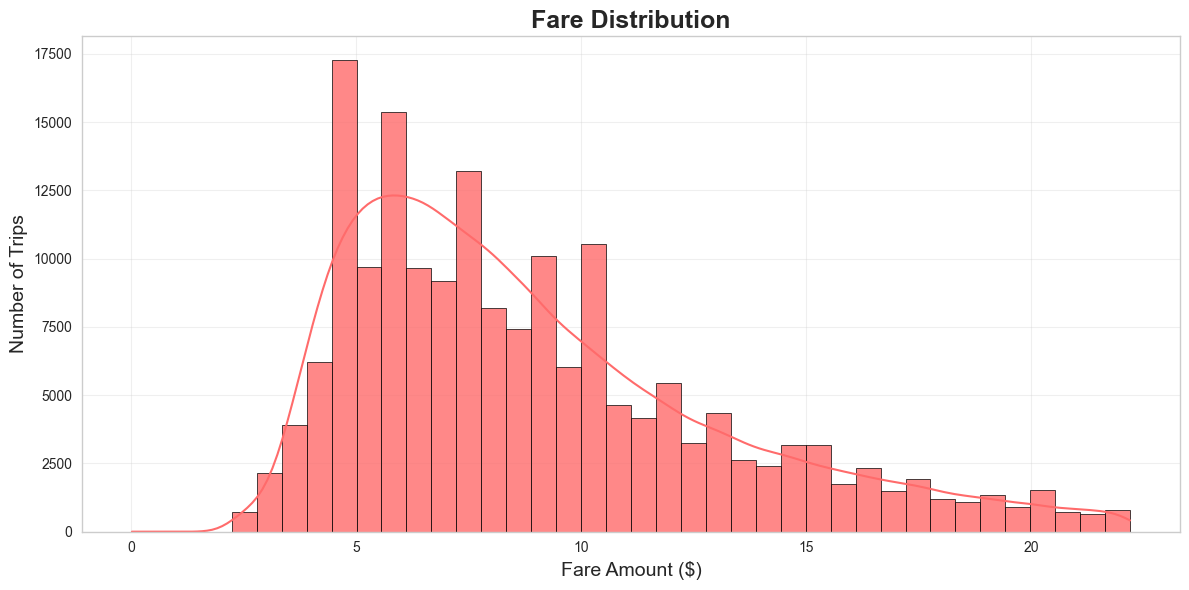

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="fare_amount",
    bins=40,
    kde=True,
    color="#FF6B6B",
    edgecolor="black",
    alpha=0.8
)

plt.title("Fare Distribution", fontsize=18, fontweight="bold")
plt.xlabel("Fare Amount ($)", fontsize=14)
plt.ylabel("Number of Trips", fontsize=14)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    r"C:\Users\Nithin\OneDrive\Desktop\Projects\Spatial–Temporal Uber Fare Prediction Engine\Images\01_fare_distribution.png",
    dpi=300
)

plt.show()

C:\Users\Nithin\AppData\Local\Temp\ipykernel_24000\4241077689.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


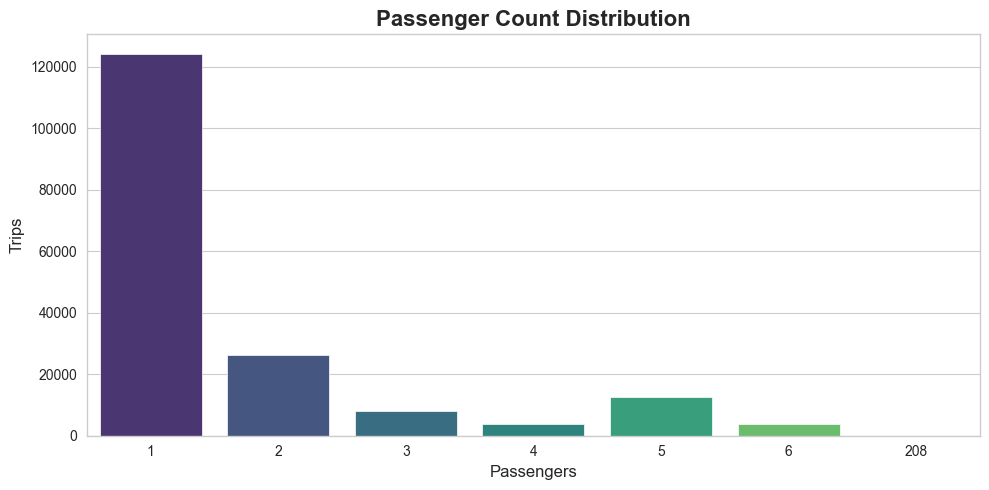

In [49]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="passenger_count",
    palette="viridis"
)

plt.title("Passenger Count Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Passengers")
plt.ylabel("Trips")

plt.tight_layout()

plt.savefig(
r"C:\Users\Nithin\OneDrive\Desktop\Projects\Spatial–Temporal Uber Fare Prediction Engine\Images\02_passenger_count.png",
dpi=300
)

plt.show()

C:\Users\Nithin\AppData\Local\Temp\ipykernel_24000\1772807422.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


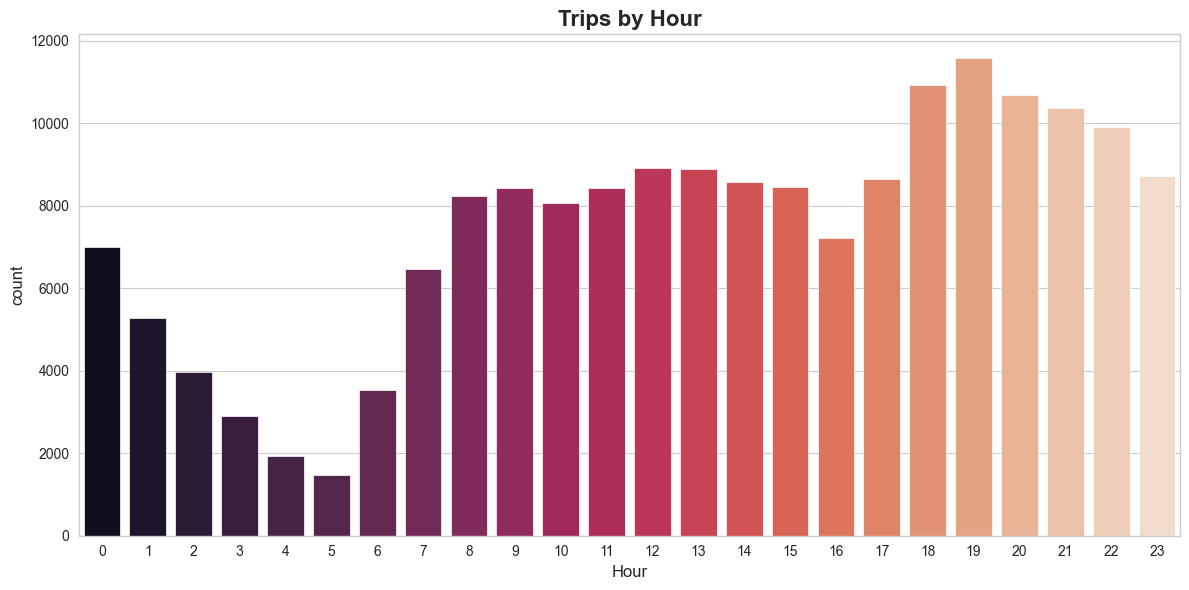

In [51]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="Hour",
    palette="rocket"
)

plt.title("Trips by Hour", fontsize=16, fontweight="bold")

plt.tight_layout()

plt.savefig(
r"C:\Users\Nithin\OneDrive\Desktop\Projects\Spatial–Temporal Uber Fare Prediction Engine\Images\03_trips_by_hour.png",
dpi=300
)

plt.show()

C:\Users\Nithin\AppData\Local\Temp\ipykernel_24000\3300936706.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


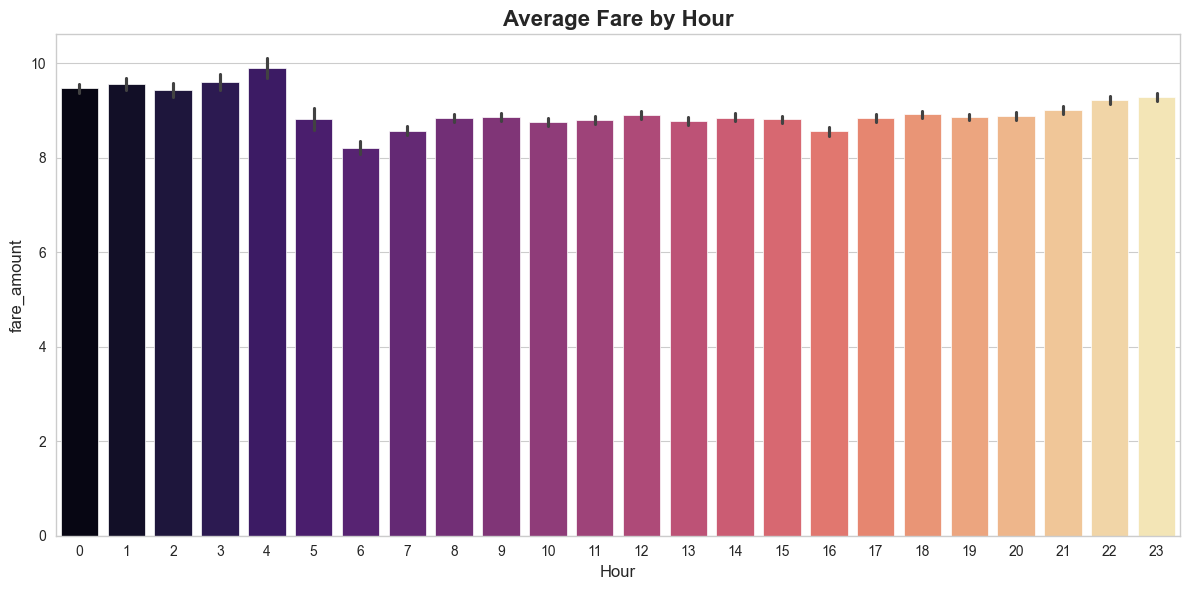

In [53]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x="Hour",
    y="fare_amount",
    estimator="mean",
    palette="magma"
)

plt.title("Average Fare by Hour", fontsize=16, fontweight="bold")

plt.tight_layout()

plt.savefig(
r"C:\Users\Nithin\OneDrive\Desktop\Projects\Spatial–Temporal Uber Fare Prediction Engine\Images\04_avg_fare_hour.png",
dpi=300
)

plt.show()

C:\Users\Nithin\AppData\Local\Temp\ipykernel_24000\4018901655.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


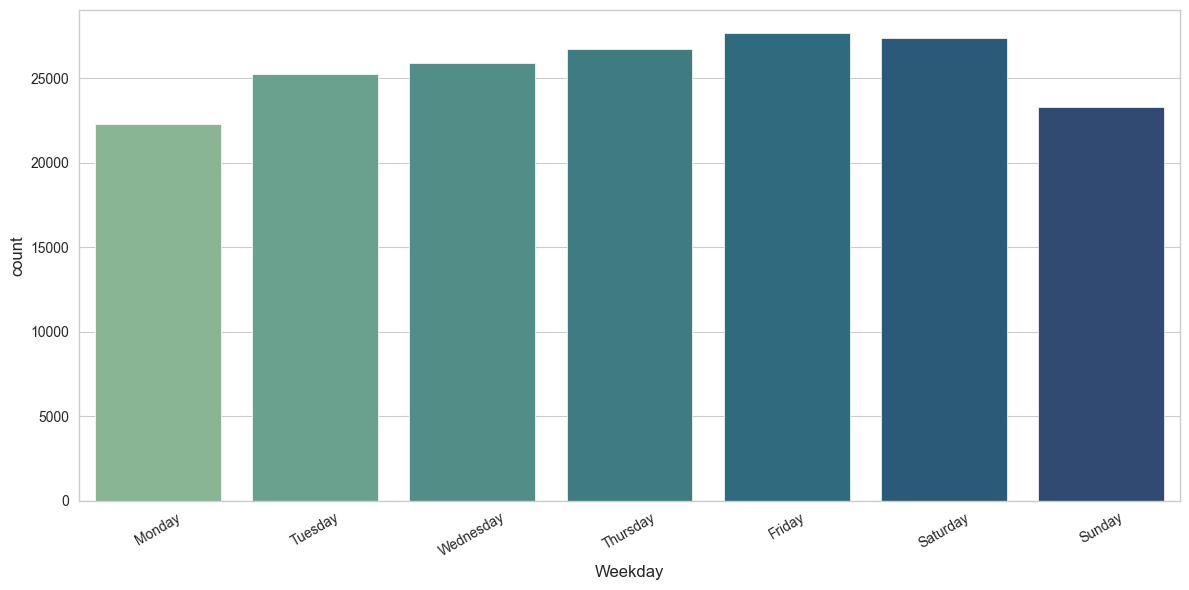

In [55]:
order = [
"Monday",
"Tuesday",
"Wednesday",
"Thursday",
"Friday",
"Saturday",
"Sunday"
]

plt.figure(figsize=(12,6))

sns.countplot(
data=df,
x="Weekday",
order=order,
palette="crest"
)

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
r"C:\Users\Nithin\OneDrive\Desktop\Projects\Spatial–Temporal Uber Fare Prediction Engine\Images\05_weekday.png",
dpi=300
)

plt.show()

C:\Users\Nithin\AppData\Local\Temp\ipykernel_24000\218026698.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


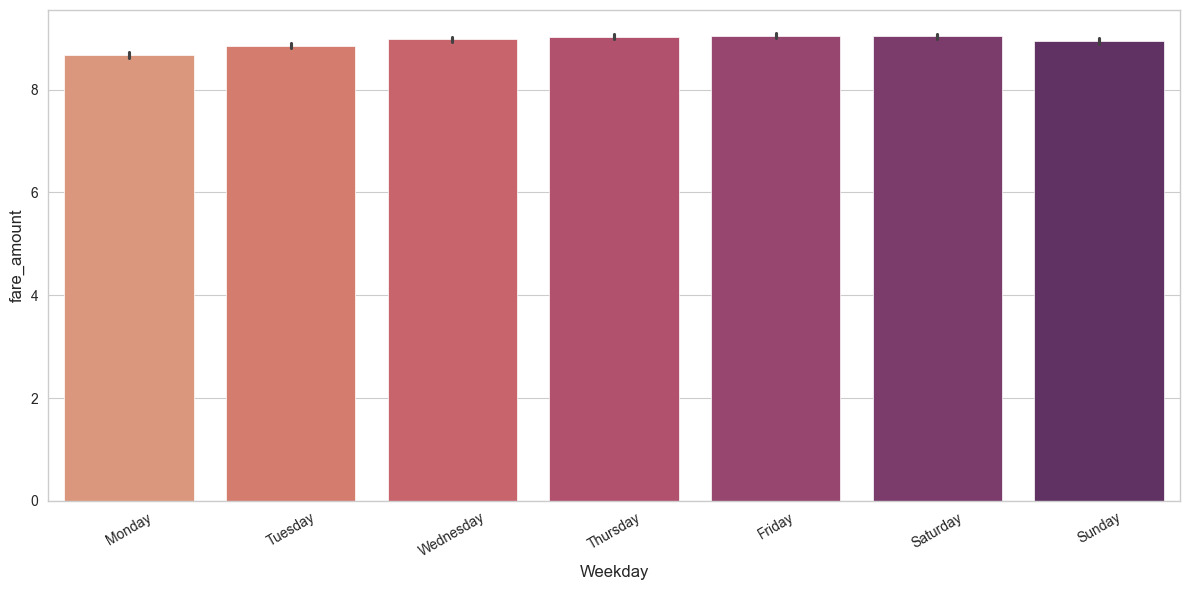

In [57]:
plt.figure(figsize=(12,6))

sns.barplot(
data=df,
x="Weekday",
y="fare_amount",
order=order,
palette="flare"
)

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
r"C:\Users\Nithin\OneDrive\Desktop\Projects\Spatial–Temporal Uber Fare Prediction Engine\Images\06_avg_fare_weekday.png",
dpi=300
)

plt.show()

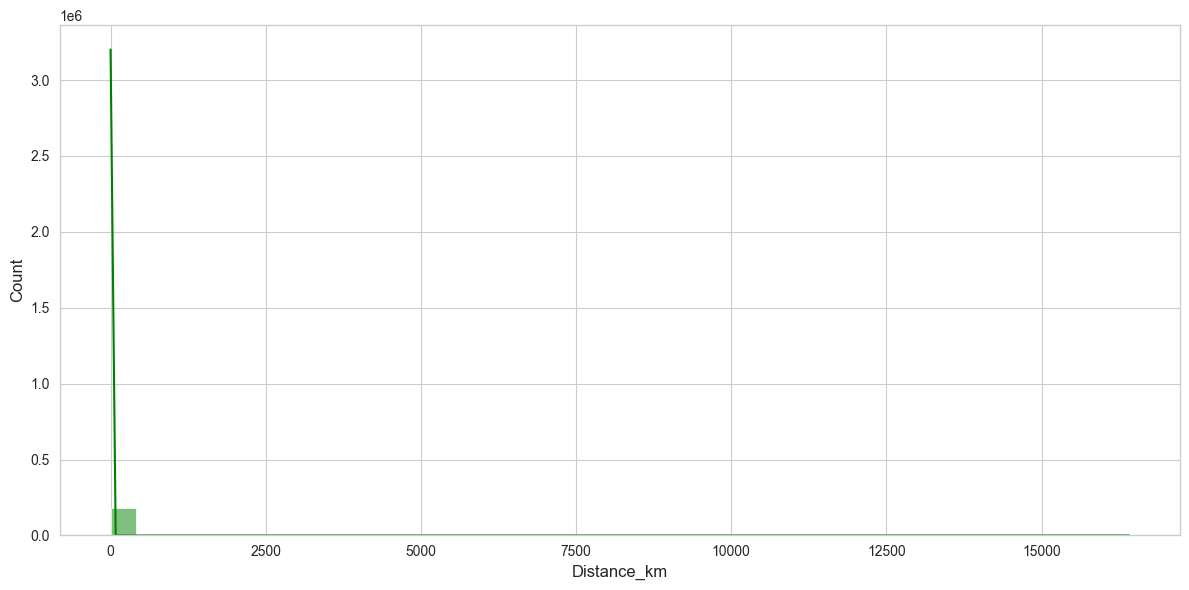

In [59]:
plt.figure(figsize=(12,6))

sns.histplot(
df["Distance_km"],
bins=40,
kde=True,
color="green"
)

plt.tight_layout()

plt.savefig(
r"C:\Users\Nithin\OneDrive\Desktop\Projects\Spatial–Temporal Uber Fare Prediction Engine\Images\07_distance_distribution.png",
dpi=300
)

plt.show()

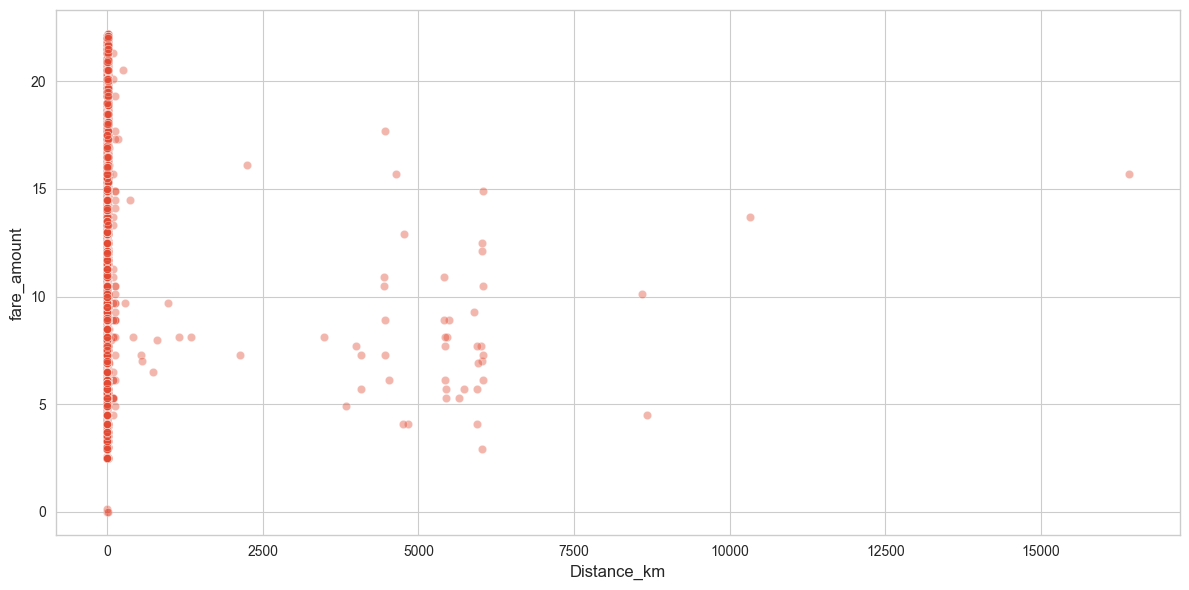

In [61]:
plt.figure(figsize=(12,6))

sns.scatterplot(
data=df,
x="Distance_km",
y="fare_amount",
alpha=0.4
)

plt.tight_layout()

plt.savefig(
r"C:\Users\Nithin\OneDrive\Desktop\Projects\Spatial–Temporal Uber Fare Prediction Engine\Images\08_distance_vs_fare.png",
dpi=300
)

plt.show()

C:\Users\Nithin\AppData\Local\Temp\ipykernel_24000\4148889239.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


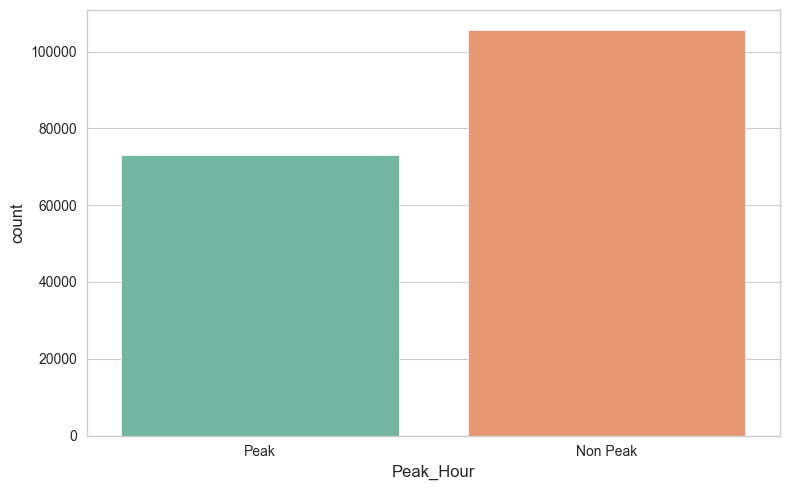

In [63]:
plt.figure(figsize=(8,5))

sns.countplot(
data=df,
x="Peak_Hour",
palette="Set2"
)

plt.tight_layout()

plt.savefig(
r"C:\Users\Nithin\OneDrive\Desktop\Projects\Spatial–Temporal Uber Fare Prediction Engine\Images\09_peak_hour.png",
dpi=300
)

plt.show()

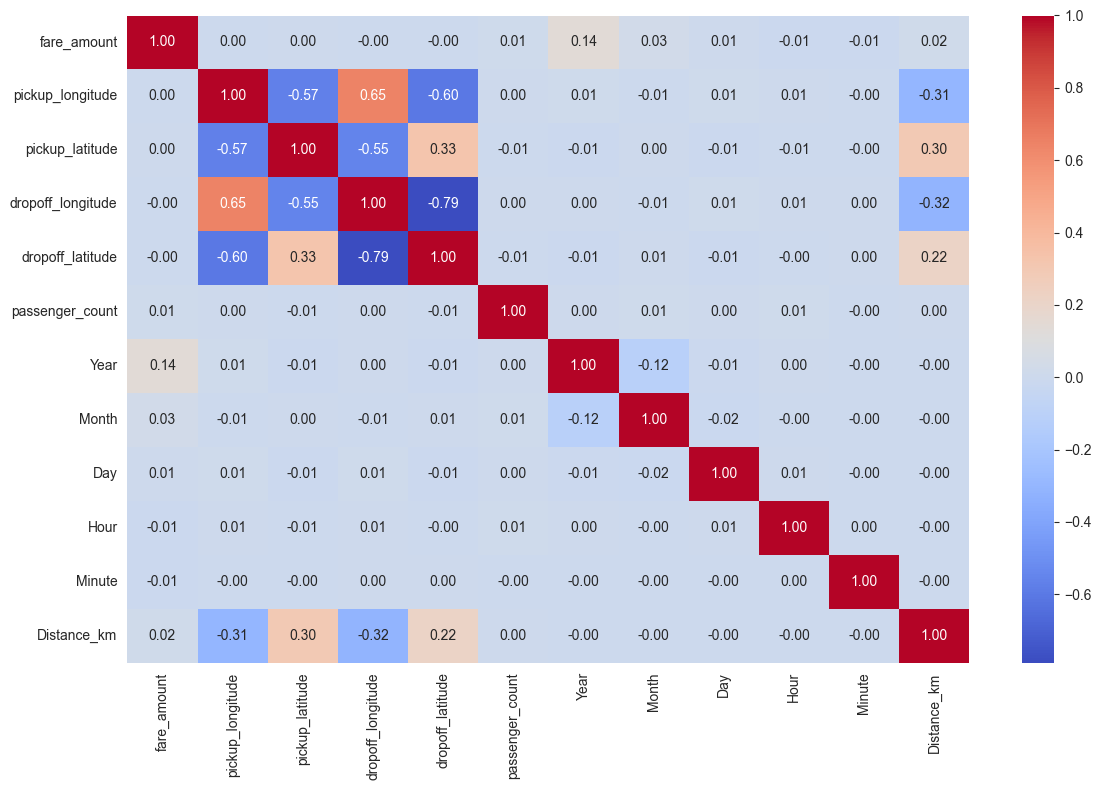

In [65]:
plt.figure(figsize=(12,8))

sns.heatmap(
df.corr(numeric_only=True),
annot=True,
cmap="coolwarm",
fmt=".2f"
)

plt.tight_layout()

plt.savefig(
r"C:\Users\Nithin\OneDrive\Desktop\Projects\Spatial–Temporal Uber Fare Prediction Engine\Images\10_heatmap.png",
dpi=300
)

plt.show()

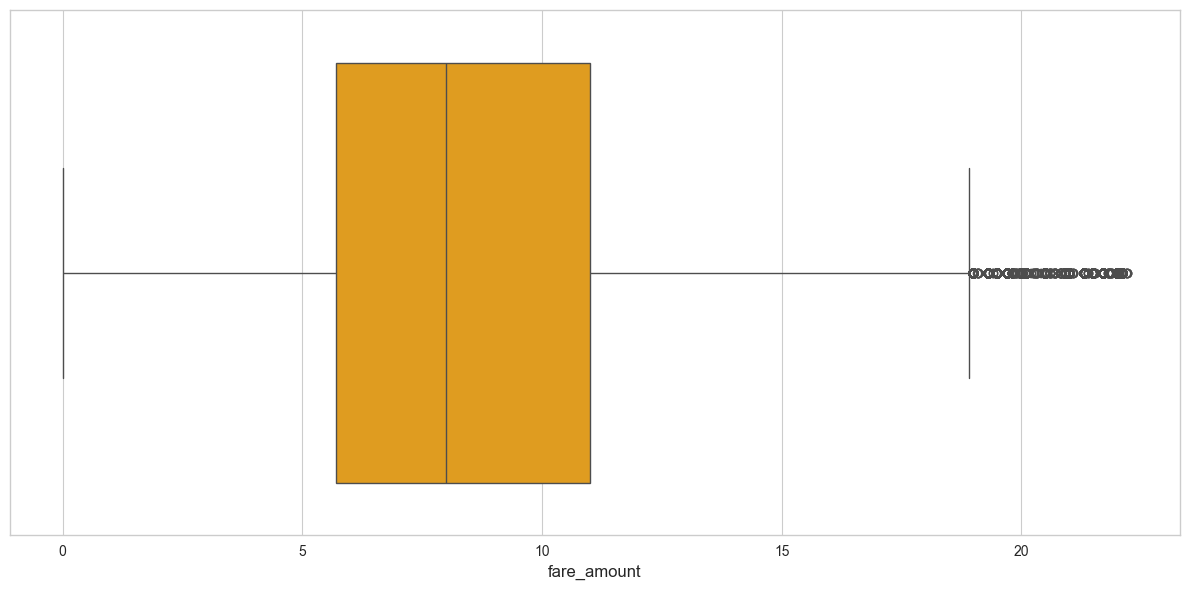

In [67]:
plt.figure(figsize=(12,6))

sns.boxplot(
x=df["fare_amount"],
color="orange"
)

plt.tight_layout()

plt.savefig(
r"C:\Users\Nithin\OneDrive\Desktop\Projects\Spatial–Temporal Uber Fare Prediction Engine\Images\11_boxplot.png",
dpi=300
)

plt.show()

### Observation

• Most rides cost between $5 and $10.

• Distance and fare show a strong positive relationship.

• Rush hours generate more trips.

• Weekend demand is slightly higher than weekdays.

• Passenger count has little effect on fare compared to distance.